In [3]:
# --- 1) Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# تحسين العرض
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

----- Head -----


,Name,Department,Job Role,Age,Gender,Salary,Experience (Years),Education Level,Location,Performance Score,Employment Status,Promotion Last Year,Overtime,Marital Status,Attendance Rate (%)
0,David Adams,Sales,Account Manager,50,Female,85747,35,High School,Florida,4.4,Contract,No,No,Married,95
1,James Davis,Operations,Quality Assurance,58,Female,75156,16,Master's,New York,4.0,Part-time,No,No,Divorced,93
2,Mark Walker,Marketing,Content Creator,38,Female,55053,0,Master's,Texas,3.9,Contract,Yes,No,Single,99
3,David Lewis,Finance,Accountant,49,Female,71213,26,Bachelor's,Illinois,1.4,Contract,No,Yes,Married,85
4,Sophia Green,Sales,Account Manager,29,Female,66543,25,Master's,Washington,1.6,Part-time,No,No,Single,76


---- Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Name                 1000 non-null   object 
 1   Department           1000 non-null   object 
 2   Job Role             1000 non-null   object 
 3   Age                  1000 non-null   int64  
 4   Gender               1000 non-null   object 
 5   Salary               1000 non-null   int64  
 6   Experience (Years)   1000 non-null   int64  
 7   Education Level      1000 non-null   object 
 8   Location             1000 non-null   object 
 9   Performance Score    1000 non-null   float64
 10  Employment Status    1000 non-null   object 
 11  Promotion Last Year  1000 non-null   object 
 12  Overtime             1000 non-null   object 
 13  Marital Status       1000 non-null   object 
 14  Attendance Rate (%)  1000 non-null   int64  
dtypes: float64(1), int64(4),

,Name,Department,Job Role,Age,Gender,Salary,Experience (Years),Education Level,Location,Performance Score,Employment Status,Promotion Last Year,Overtime,Marital Status,Attendance Rate (%)
count,1000,1000,1000,1000.000000,1000,1000.000000,1000.000000,1000,1000,1000.00000,1000,1000,1000,1000,1000.000000
unique,366,6,19,NaN,2,NaN,NaN,4,6,NaN,3,2,2,3,NaN
top,Linda Taylor,HR,HR Coordinator,NaN,Female,NaN,NaN,Bachelor's,Florida,NaN,Full-time,Yes,No,Divorced,NaN
freq,9,184,81,NaN,501,NaN,NaN,264,179,NaN,348,507,525,344,NaN
mean,NaN,NaN,NaN,40.239000,NaN,89315.115000,17.851000,NaN,NaN,3.00610,NaN,NaN,NaN,NaN,85.303000
std,NaN,NaN,NaN,11.600709,NaN,33741.345128,10.381357,NaN,NaN,1.14458,NaN,NaN,NaN,NaN,9.018455
min,NaN,NaN,NaN,21.000000,NaN,30071.000000,0.000000,NaN,NaN,1.00000,NaN,NaN,NaN,NaN,70.000000
25%,NaN,NaN,NaN,30.000000,NaN,60017.250000,9.000000,NaN,NaN,2.00000,NaN,NaN,NaN,NaN,77.750000
50%,NaN,NaN,NaN,41.000000,NaN,89973.000000,18.000000,NaN,NaN,3.00000,NaN,NaN,NaN,NaN,85.000000
75%,NaN,NaN,NaN,51.000000,NaN,118461.750000,27.000000,NaN,NaN,4.00000,NaN,NaN,NaN,NaN,93.000000



Missing Values:
Name                   0
Department             0
Job Role               0
Age                    0
Gender                 0
Salary                 0
Experience (Years)     0
Education Level        0
Location               0
Performance Score      0
Employment Status      0
Promotion Last Year    0
Overtime               0
Marital Status         0
Attendance Rate (%)    0
dtype: int64

Number of Employees: 1000

Employees per Department:


Department
HR            184
Sales         175
Finance       174
Marketing     159
Operations    156
IT            152
Name: count, dtype: int64


Employees by Gender:


Gender
Female    501
Male      499
Name: count, dtype: int64


Salary Statistics:


count      1000.000000
mean      89315.115000
std       33741.345128
min       30071.000000
25%       60017.250000
50%       89973.000000
75%      118461.750000
max      149905.000000
Name: Salary, dtype: float64

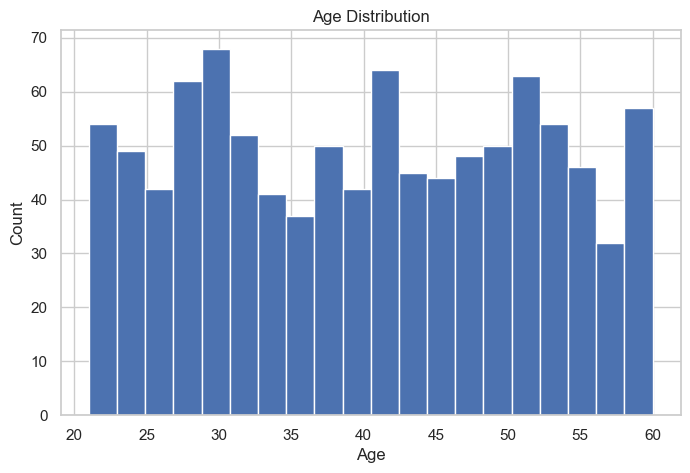

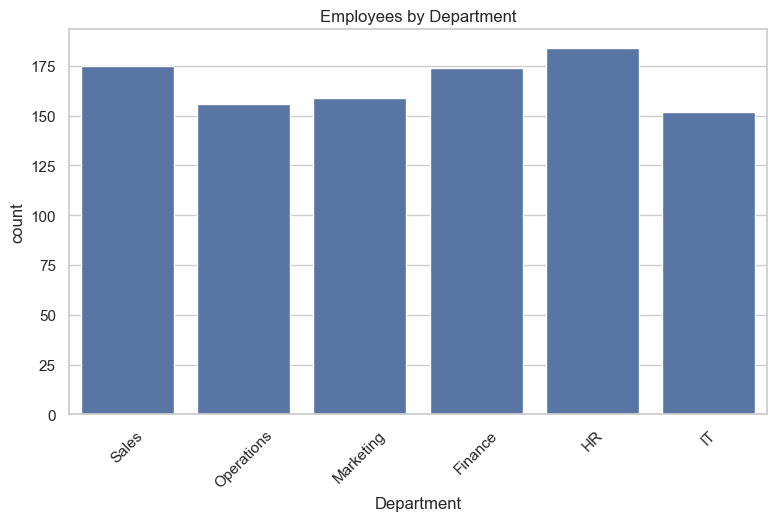

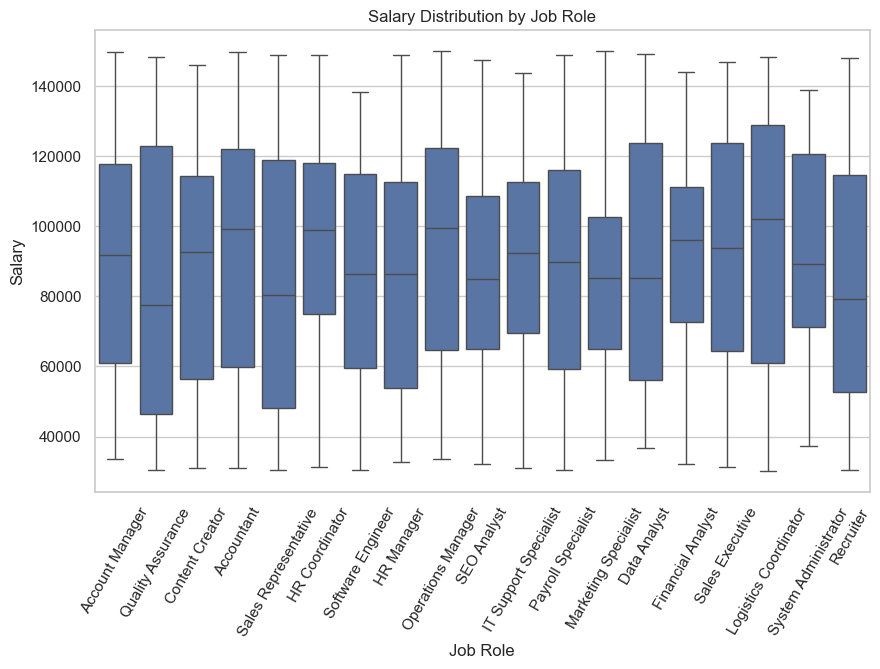

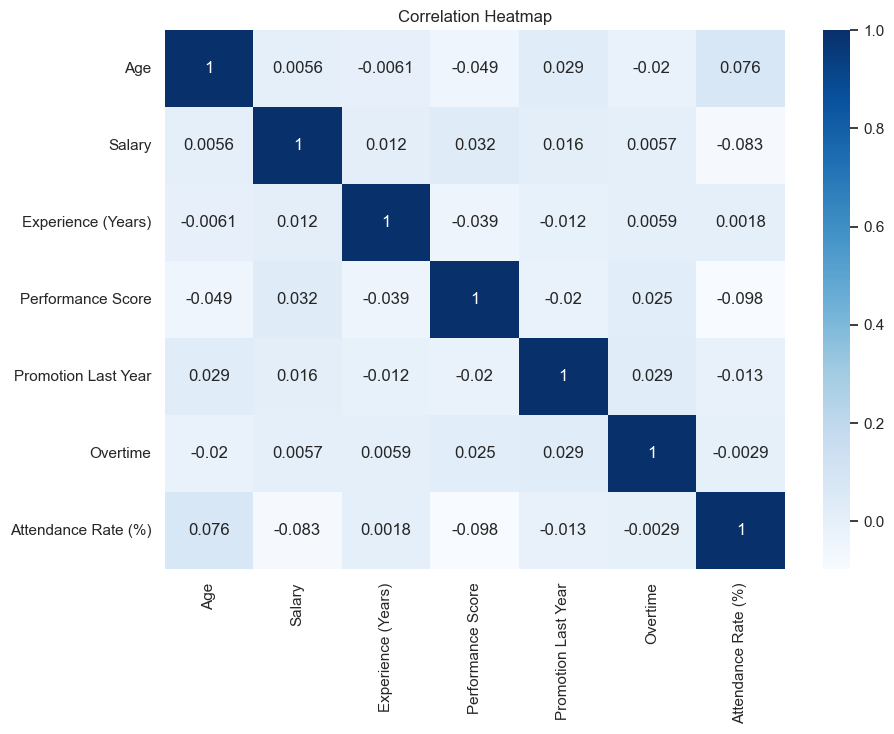


----- Key Insights -----
• Average Salary: 89315.115
• Youngest Employee: 21
• Oldest Employee: 60

• Highest Paying Department:
Department
Finance    91661.149425
Name: Salary, dtype: float64

Analysis Completed Successfully ✔


In [6]:
# --- 2) Load Dataset ---
file_path = r"F:\Data Analysis Projects\HR Project Dashboard\Dataset\HR Dataset.csv"
df = pd.read_csv(file_path)

print("----- Head -----")
display(df.head())

print("---- Info ----")
df.info()

print("---- Summary ----")
display(df.describe(include="all"))

# --- 3) Data Cleaning ---
print("\nMissing Values:")
print(df.isna().sum())

# إزالة التكرارات
df.drop_duplicates(inplace=True)

# تحويل Yes/No إلى 1/0 (لو موجودة)
for col in df.columns:
    if df[col].astype(str).str.lower().isin(["yes", "no"]).any():
        df[col] = df[col].map({"Yes": 1, "No": 0})

# --- 4) Basic HR KPIs ---
print("\nNumber of Employees:", len(df))

if "Department" in df.columns:
    print("\nEmployees per Department:")
    display(df["Department"].value_counts())

if "Gender" in df.columns:
    print("\nEmployees by Gender:")
    display(df["Gender"].value_counts())

if "Salary" in df.columns:
    print("\nSalary Statistics:")
    display(df["Salary"].describe())

# --- 5) Visualizations ---

# Histogram – Age
if "Age" in df.columns:
    plt.figure(figsize=(8,5))
    plt.hist(df["Age"].dropna(), bins=20)
    plt.title("Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()

# Department Countplot
if "Department" in df.columns:
    plt.figure(figsize=(9,5))
    sns.countplot(data=df, x="Department")
    plt.xticks(rotation=45)
    plt.title("Employees by Department")
    plt.show()

# Salary by Job Role
if "Job Role" in df.columns and "Salary" in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(data=df, x="Job Role", y="Salary")
    plt.xticks(rotation=60)
    plt.title("Salary Distribution by Job Role")
    plt.show()

# --- Correlation Heatmap (Fixed) ---
# اختيار الأعمدة الرقمية فقط لتجنب الأخطاء
numeric_df = df.select_dtypes(include=['int64', 'float64'])

if not numeric_df.empty:
    plt.figure(figsize=(10,7))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("\n⚠ No numeric columns available for correlation heatmap.")

# --- 6) Attrition Analysis ---
if "Attrition" in df.columns:
    print("\nAttrition Rate:")
    rate = df["Attrition"].mean() * 100
    print(f"Attrition: {rate:.2f}%")

    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x="Attrition")
    plt.title("Attrition Count")
    plt.show()

# --- 7) Insights ---
print("\n----- Key Insights -----")

if "Salary" in df.columns:
    print("• Average Salary:", df["Salary"].mean())

if "Age" in df.columns:
    print("• Youngest Employee:", df["Age"].min())
    print("• Oldest Employee:", df["Age"].max())

if {"Department", "Salary"}.issubset(df.columns):
    dep_salary = df.groupby("Department")["Salary"].mean().sort_values(ascending=False)
    print("\n• Highest Paying Department:")
    print(dep_salary.head(1))

print("\nAnalysis Completed Successfully ✔")